In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from kmodes.kmodes import KModes # Usado para clustering de datos categóricos/mixtos
from scipy.spatial.distance import cdist

# Configuración para mejor visualización
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# Cargar el dataset
df = pd.read_csv("data//clientes.csv")
df.columns


Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [2]:

# Columnas seleccionadas
categorical_cols = ['Customer type', 'Gender', 'Product line', 'Payment','Date']
numerical_cols = ['Total', 'Quantity', 'Unit price', 'Rating']

all_selected_cols = categorical_cols + numerical_cols

# Filtrar el DataFrame
df_eda = df[all_selected_cols].copy()

# --- EDA BÁSICO ---
print("--- EDA Básico: Información General ---")
print(df_eda.info())
print("\n--- Estadísticas Descriptivas (Numéricas) ---")
print(df_eda[numerical_cols].describe())

# Distribución de las Categóricas
print("\n--- Conteo de Valores (Categóricas) ---")
for col in categorical_cols:
    print(f"\nDistribución de '{col}':")
    print(df_eda[col].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Verificar valores nulos
print(f"\nValores Nulos:\n{df_eda.isnull().sum()}")

# 💡 Comentario de Experto: No se observan nulos y las distribuciones categóricas parecen balanceadas,
# aunque 'Payment' tiene tres categorías bien distribuidas y 'Product line' muestra 6 categorías.

--- EDA Básico: Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Customer type  1000 non-null   object 
 1   Gender         1000 non-null   object 
 2   Product line   1000 non-null   object 
 3   Payment        1000 non-null   object 
 4   Date           1000 non-null   object 
 5   Total          1000 non-null   float64
 6   Quantity       1000 non-null   int64  
 7   Unit price     1000 non-null   float64
 8   Rating         1000 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 70.4+ KB
None

--- Estadísticas Descriptivas (Numéricas) ---
             Total     Quantity   Unit price      Rating
count  1000.000000  1000.000000  1000.000000  1000.00000
mean    322.966749     5.510000    55.672130     6.97270
std     245.885335     2.923431    26.494628     1.71858
min      10.678500     1.000

In [3]:
# Crear diccionario para reducir nombres de Product line a 1 palabra
product_line_mapping = {
    'Electronic accessories': 'Electronics',
    'Fashion accessories': 'Fashion',
    'Food and beverages': 'Food',
    'Health and beauty': 'Health',
    'Home and lifestyle': 'Home',
    'Sports and travel': 'Sports'
}

# Mostrar el mapeo
print("Mapeo de Product line:")
print("Original -> Reducido")
print("-" * 30)
for original, reduced in product_line_mapping.items():
    print(f"{original} -> {reduced}")

# Aplicar el mapeo al DataFrame original
df['Product line'] = df['Product line'].map(product_line_mapping)

# También aplicar al DataFrame de EDA
df_eda['Product line'] = df_eda['Product line'].map(product_line_mapping)

# Verificar los cambios
print(f"\nNuevos valores únicos en Product line:")
print(df['Product line'].unique())
print(f"\nConteo de valores en el DataFrame original:")
print(df['Product line'].value_counts())

Mapeo de Product line:
Original -> Reducido
------------------------------
Electronic accessories -> Electronics
Fashion accessories -> Fashion
Food and beverages -> Food
Health and beauty -> Health
Home and lifestyle -> Home
Sports and travel -> Sports

Nuevos valores únicos en Product line:
['Health' 'Electronics' 'Home' 'Sports' 'Food' 'Fashion']

Conteo de valores en el DataFrame original:
Product line
Fashion        178
Food           174
Electronics    170
Sports         166
Home           160
Health         152
Name: count, dtype: int64


In [4]:
# Crear la variable categórica de Rating agrupada
def categorize_rating(rating):
    if rating < 5:
        return 'Malo'
    elif rating < 8:
        return 'Bueno'
    else:
        return 'Muy bueno'

# Aplicar la categorización al DataFrame original
df['Rating_Category'] = df['Rating'].apply(categorize_rating)

# También aplicar al DataFrame de EDA
df_eda['Rating_Category'] = df_eda['Rating'].apply(categorize_rating)

# Verificar la distribución de las nuevas categorías
print("--- Distribución de Rating Categórico ---")
print("Conteo:")
print(df['Rating_Category'].value_counts().sort_index())
print("\nPorcentajes:")
print(df['Rating_Category'].value_counts(normalize=True).mul(100).round(2).sort_index().astype(str) + '%')

# Mostrar estadísticas del Rating original por categoría
print("\n--- Estadísticas de Rating Original por Categoría ---")
rating_stats = df.groupby('Rating_Category')['Rating'].agg(['min', 'max', 'mean', 'count'])
print(rating_stats)

# Actualizar la lista de columnas categóricas para incluir la nueva variable
categorical_cols_updated = categorical_cols + ['Rating_Category']
print(f"\nColumnas categóricas actualizadas: {categorical_cols_updated}")

--- Distribución de Rating Categórico ---
Conteo:
Rating_Category
Bueno        518
Malo         153
Muy bueno    329
Name: count, dtype: int64

Porcentajes:
Rating_Category
Bueno        51.8%
Malo         15.3%
Muy bueno    32.9%
Name: proportion, dtype: object

--- Estadísticas de Rating Original por Categoría ---
                 min   max      mean  count
Rating_Category                            
Bueno            5.0   7.9  6.452317    518
Malo             4.0   4.9  4.435294    153
Muy bueno        8.0  10.0  8.972036    329

Columnas categóricas actualizadas: ['Customer type', 'Gender', 'Product line', 'Payment', 'Date', 'Rating_Category']


In [5]:
# Columnas seleccionadas para análisis posterior
categorical_cols = ['Customer type', 'Gender', 'Product line', 'Payment', 'Rating_Category', 'Date']
numerical_cols = ['Total', 'Quantity', 'Unit price']

# Crear el nuevo DataFrame con las columnas actualizadas
all_selected_cols = categorical_cols + numerical_cols
df_eda = df[all_selected_cols].copy()

print("--- Columnas Seleccionadas para Análisis ---")
print(f"Categóricas: {categorical_cols}")
print(f"Numéricas: {numerical_cols}")
print(f"\nDimensiones del nuevo DataFrame: {df_eda.shape}")
print(f"\nPrimeras 5 filas:")
print(df_eda.head())

# Verificar que no hay valores nulos en las nuevas columnas
print(f"\nValores nulos en el DataFrame actualizado:")
print(df_eda.isnull().sum())

--- Columnas Seleccionadas para Análisis ---
Categóricas: ['Customer type', 'Gender', 'Product line', 'Payment', 'Rating_Category', 'Date']
Numéricas: ['Total', 'Quantity', 'Unit price']

Dimensiones del nuevo DataFrame: (1000, 9)

Primeras 5 filas:
  Customer type  Gender Product line      Payment Rating_Category       Date  \
0        Member  Female       Health      Ewallet       Muy bueno   1/5/2019   
1        Normal  Female  Electronics         Cash       Muy bueno   3/8/2019   
2        Normal    Male         Home  Credit card           Bueno   3/3/2019   
3        Member    Male       Health      Ewallet       Muy bueno  1/27/2019   
4        Normal    Male       Sports      Ewallet           Bueno   2/8/2019   

      Total  Quantity  Unit price  
0  548.9715         7       74.69  
1   80.2200         5       15.28  
2  340.5255         7       46.33  
3  489.0480         8       58.22  
4  634.3785         7       86.31  

Valores nulos en el DataFrame actualizado:
Customer 

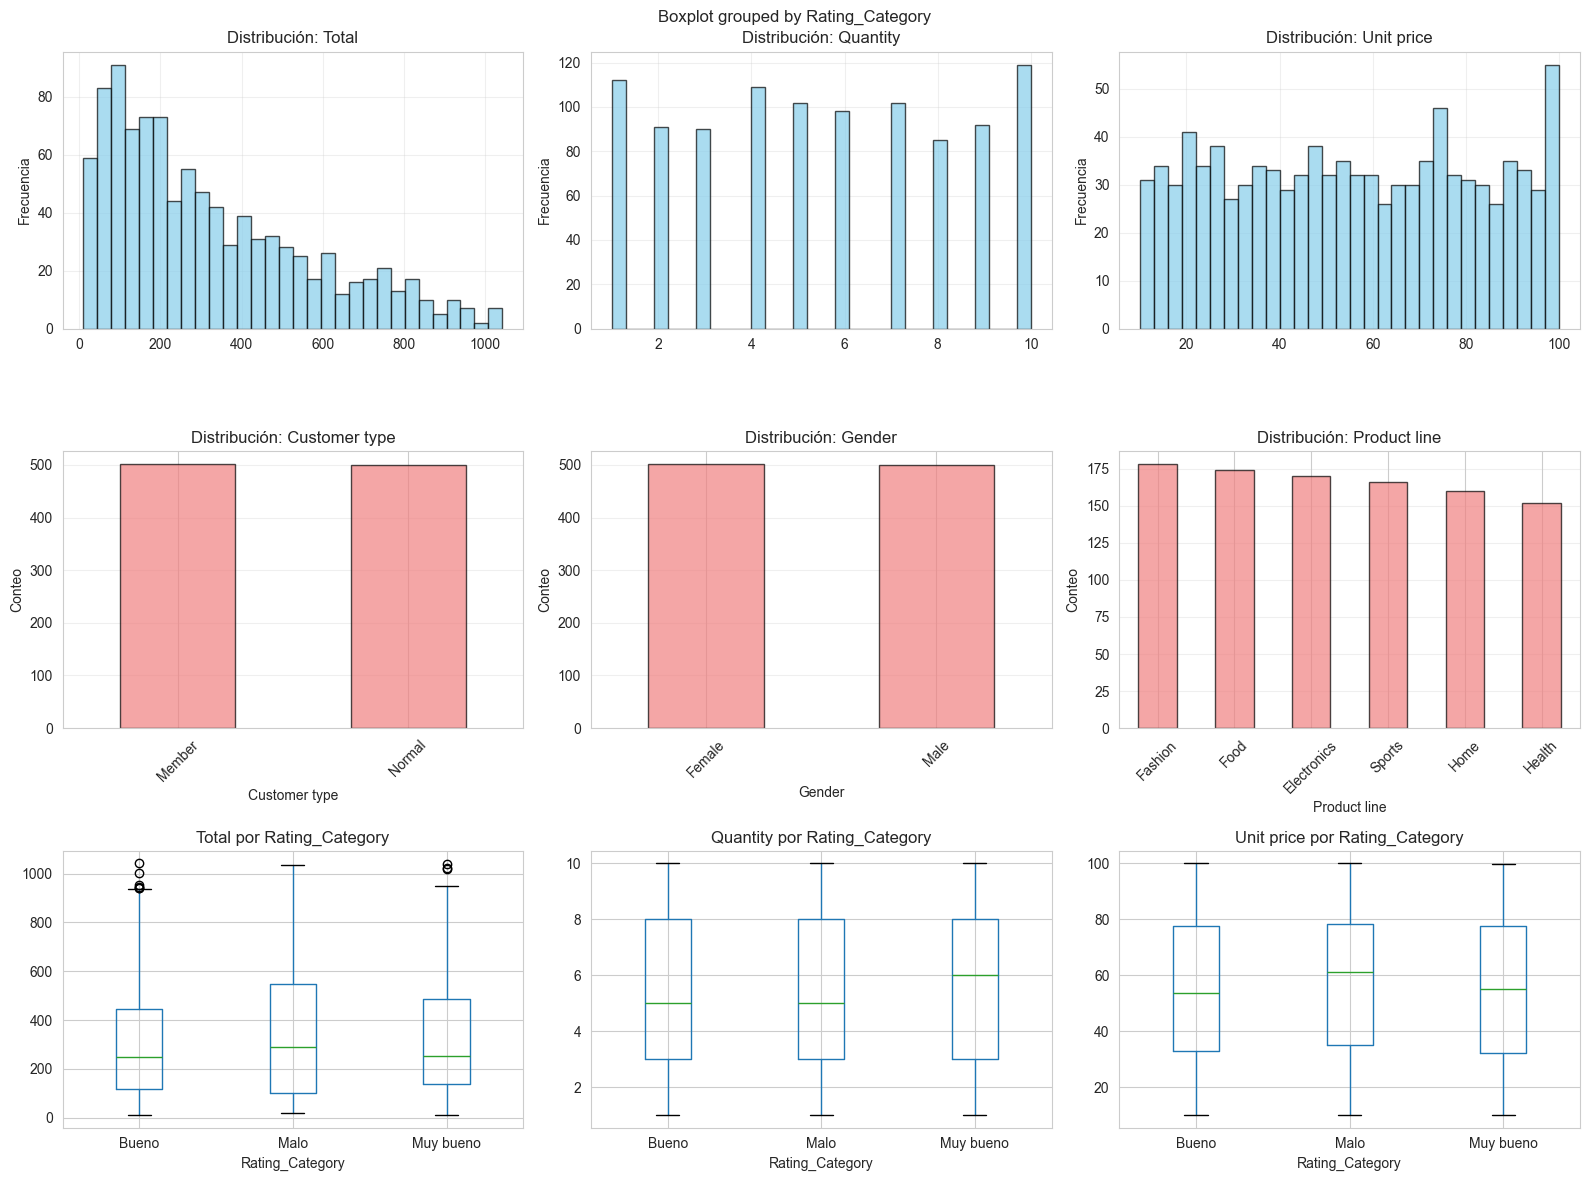


--- CORRELACIÓN ENTRE VARIABLES NUMÉRICAS ---
               Total  Quantity  Unit price
Total       1.000000  0.705510    0.633962
Quantity    0.705510  1.000000    0.010778
Unit price  0.633962  0.010778    1.000000


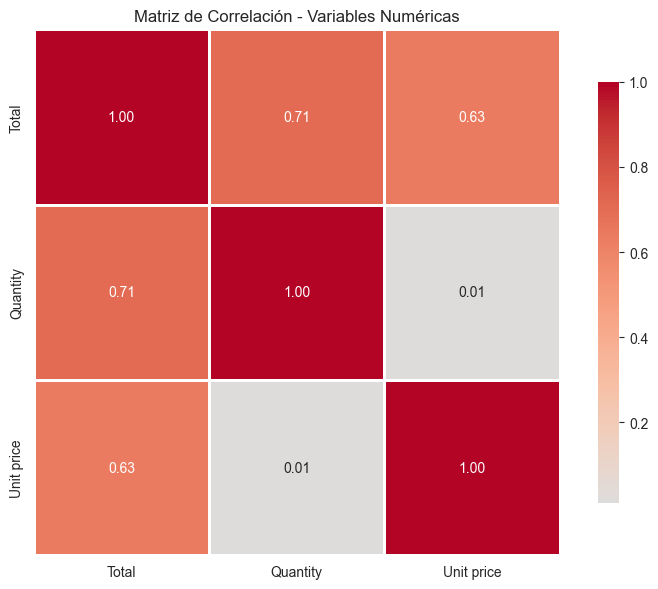


--- RESUMEN ESTADÍSTICO COMPLETO ---
             count        mean         std      min         25%      50%  \
Total       1000.0  322.966749  245.885335  10.6785  124.422375  253.848   
Quantity    1000.0    5.510000    2.923431   1.0000    3.000000    5.000   
Unit price  1000.0   55.672130   26.494628  10.0800   32.875000   55.230   

                  75%      max  
Total       471.35025  1042.65  
Quantity      8.00000    10.00  
Unit price   77.93500    99.96  

--- DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS ---

Customer type:
Customer type
Member    501
Normal    499
Name: count, dtype: int64
Porcentajes:
Customer type
Member    50.1
Normal    49.9
Name: proportion, dtype: float64

Gender:
Gender
Female    501
Male      499
Name: count, dtype: int64
Porcentajes:
Gender
Female    50.1
Male      49.9
Name: proportion, dtype: float64

Product line:
Product line
Fashion        178
Food           174
Electronics    170
Sports         166
Home           160
Health         152
Name: cou

In [6]:
# --- EDA GRÁFICO DE LOS DATOS ---

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('EDA Gráfico - Análisis Exploratorio de Datos', fontsize=16, fontweight='bold')

# 1. Distribución de variables numéricas
for idx, col in enumerate(numerical_cols):
    ax = axes[0, idx]
    df_eda[col].hist(bins=30, ax=ax, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribución: {col}')
    ax.set_ylabel('Frecuencia')
    ax.grid(True, alpha=0.3)

# 2. Distribución de variables categóricas (primeras 3)
categorical_to_plot = categorical_cols[:3]
for idx, col in enumerate(categorical_to_plot):
    ax = axes[1, idx]
    df_eda[col].value_counts().plot(kind='bar', ax=ax, color='lightcoral', edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribución: {col}')
    ax.set_ylabel('Conteo')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

# 3. Box plots para variables numéricas por Rating_Category
for idx, col in enumerate(numerical_cols):
    ax = axes[2, idx]
    df_eda.boxplot(column=col, by='Rating_Category', ax=ax)
    ax.set_title(f'{col} por Rating_Category')
    ax.set_xlabel('Rating_Category')
    plt.sca(ax)
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# --- Análisis de correlaciones ---
print("\n--- CORRELACIÓN ENTRE VARIABLES NUMÉRICAS ---")
correlation_matrix = df_eda[numerical_cols].corr()
print(correlation_matrix)

# Visualizar matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

# --- Resumen estadístico ---
print("\n--- RESUMEN ESTADÍSTICO COMPLETO ---")
print(df_eda[numerical_cols].describe().T)

print("\n--- DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS ---")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df_eda[col].value_counts())
    print(f"Porcentajes:\n{(df_eda[col].value_counts(normalize=True) * 100).round(2)}")

📊 ANÁLISIS BIVARIADO - RELACIONES ENTRE VARIABLES

--- 1. Análisis de Variables Numéricas por Rating_Category ---


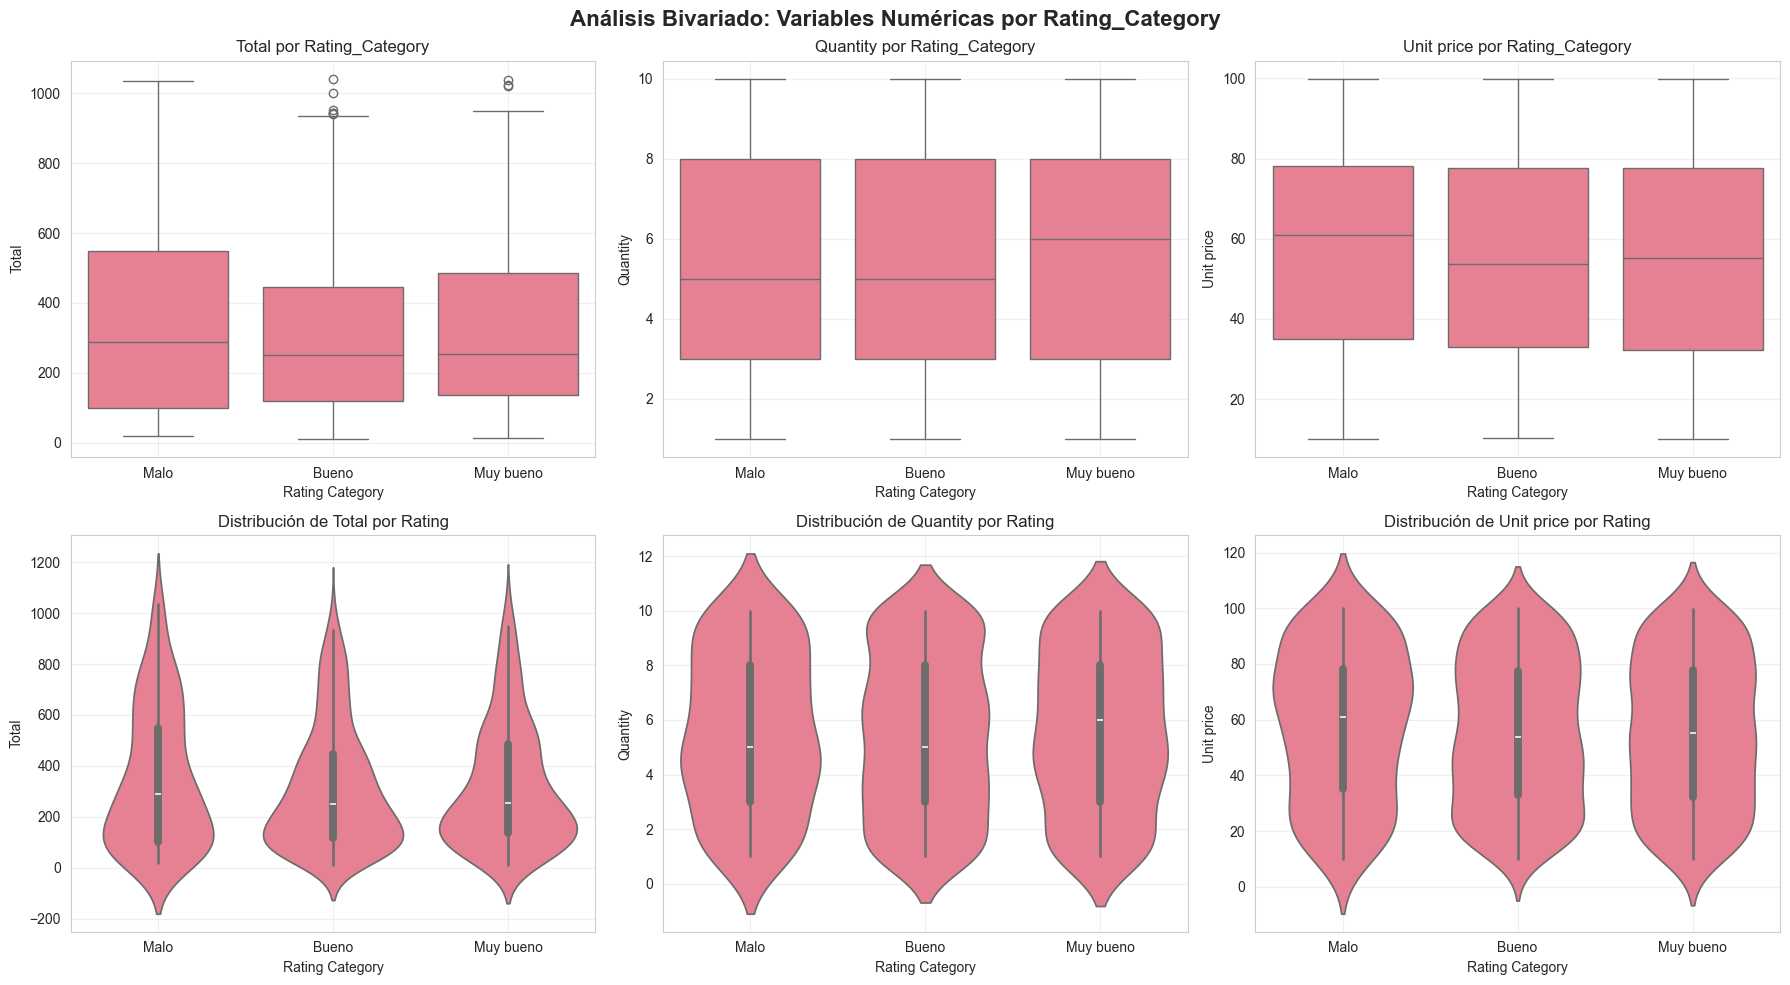


📈 Estadísticas de Variables Numéricas por Rating_Category:

--- Total ---
                   mean  median     std    min      max
Rating_Category                                        
Bueno            314.08  249.29  239.64  10.68  1042.65
Malo             352.39  288.58  272.82  19.25  1034.46
Muy bueno        323.28  252.76  242.08  12.69  1039.29

--- Quantity ---
                 mean  median   std  min  max
Rating_Category                              
Bueno            5.46     5.0  2.95    1   10
Malo             5.52     5.0  2.88    1   10
Muy bueno        5.59     6.0  2.90    1   10

--- Unit price ---
                  mean  median    std    min    max
Rating_Category                                    
Bueno            55.09   53.68  26.29  10.17  99.96
Malo             58.02   60.96  26.92  10.08  99.96
Muy bueno        55.49   55.07  26.64  10.13  99.83

--- 2. Análisis de Product Line vs Variables Numéricas ---


C:\Users\User.DESKTOP-OQGLH3N\AppData\Local\Temp\ipykernel_56760\1638451212.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eda, x='Product line', y=col, ax=axes[idx],
C:\Users\User.DESKTOP-OQGLH3N\AppData\Local\Temp\ipykernel_56760\1638451212.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eda, x='Product line', y=col, ax=axes[idx],
C:\Users\User.DESKTOP-OQGLH3N\AppData\Local\Temp\ipykernel_56760\1638451212.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eda, x='Product line', y=col, ax=axes[idx],


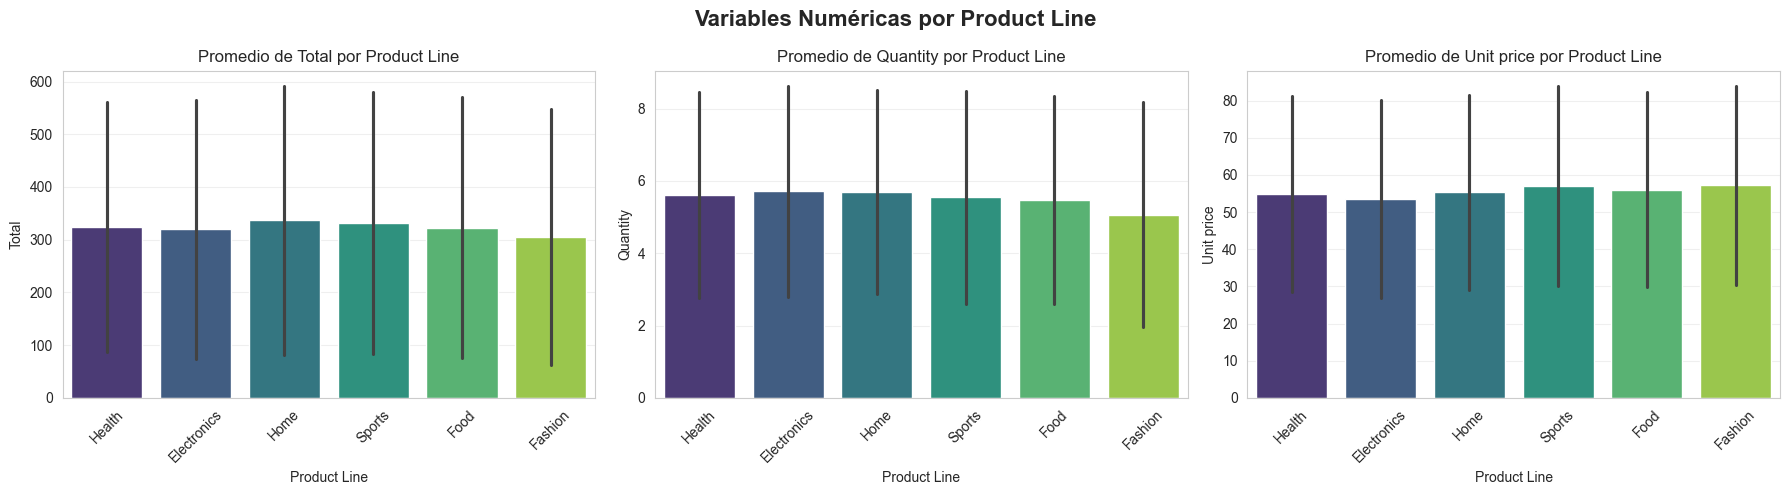


--- 3. Análisis de Gender vs Product Line ---

📊 Distribución de Product Line por Gender (%):
Product line  Electronics  Fashion   Food  Health   Home  Sports
Gender                                                          
Female              16.77    19.16  17.96   12.77  15.77   17.56
Male                17.23    16.43  16.83   17.64  16.23   15.63


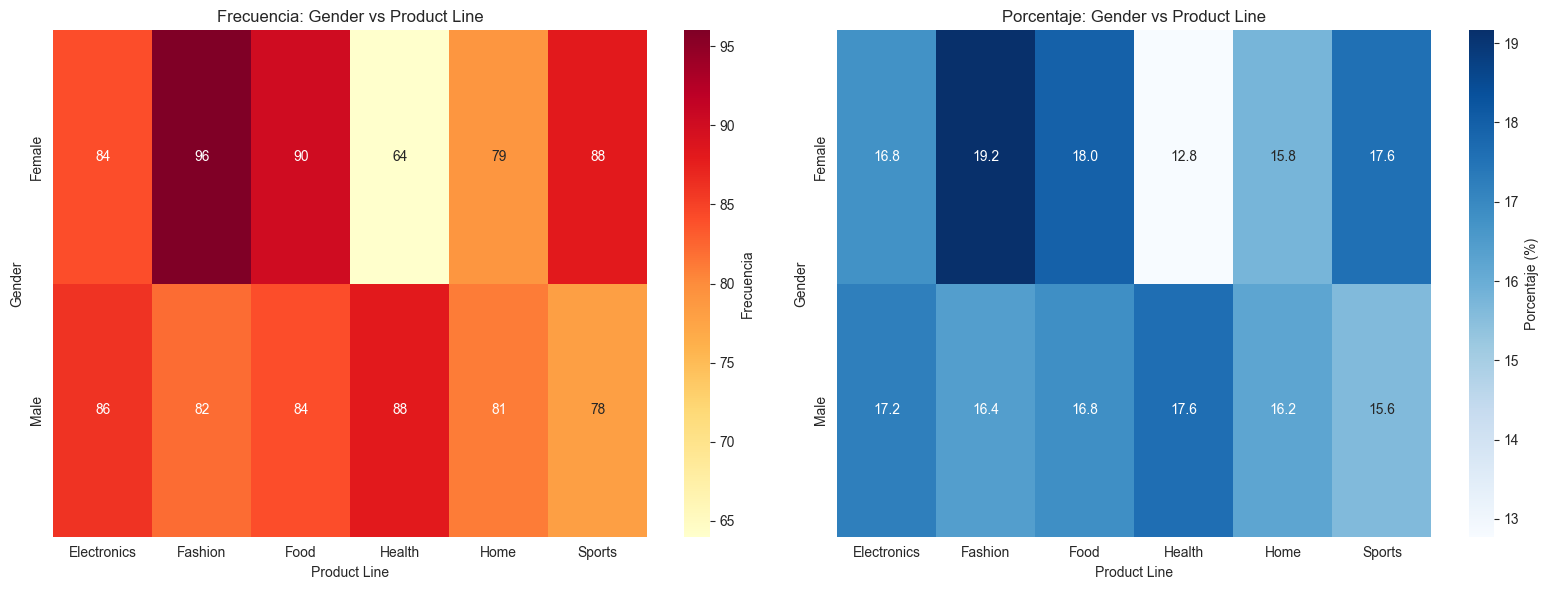


--- 4. Análisis de Customer Type vs Payment Method ---

💳 Distribución de Payment por Customer Type (%):
Payment         Cash  Credit card  Ewallet
Customer type                             
Member         33.53        34.33    32.14
Normal         35.27        27.86    36.87


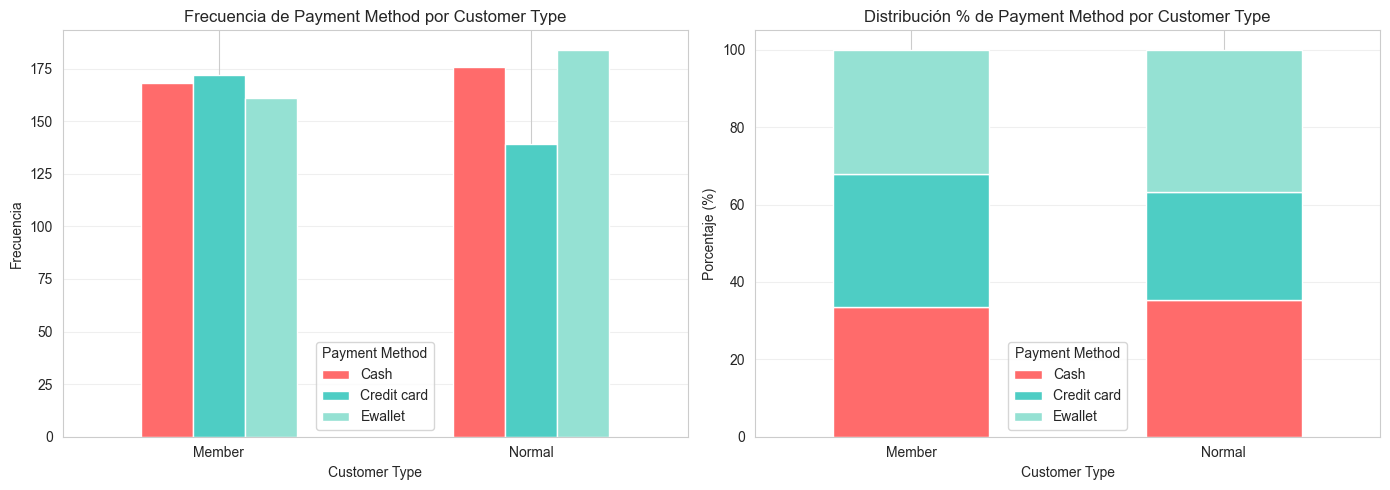


--- 5. Análisis de Gasto Total por Gender y Product Line ---

💰 Análisis de Gasto por Gender y Product Line:
                          sum    mean  count
Gender Product line                         
Female Electronics   27102.02  322.64     84
       Fashion       30437.40  317.06     96
       Food          33170.92  368.57     90
       Health        18560.99  290.02     64
       Home          30036.88  380.21     79
       Sports        28574.72  324.71     88
Male   Electronics   27235.51  316.69     86
       Fashion       23868.50  291.08     82
       Food          22973.93  273.50     84
       Health        30632.75  348.10     88
       Home          23825.04  294.14     81
       Sports        26548.11  340.36     78


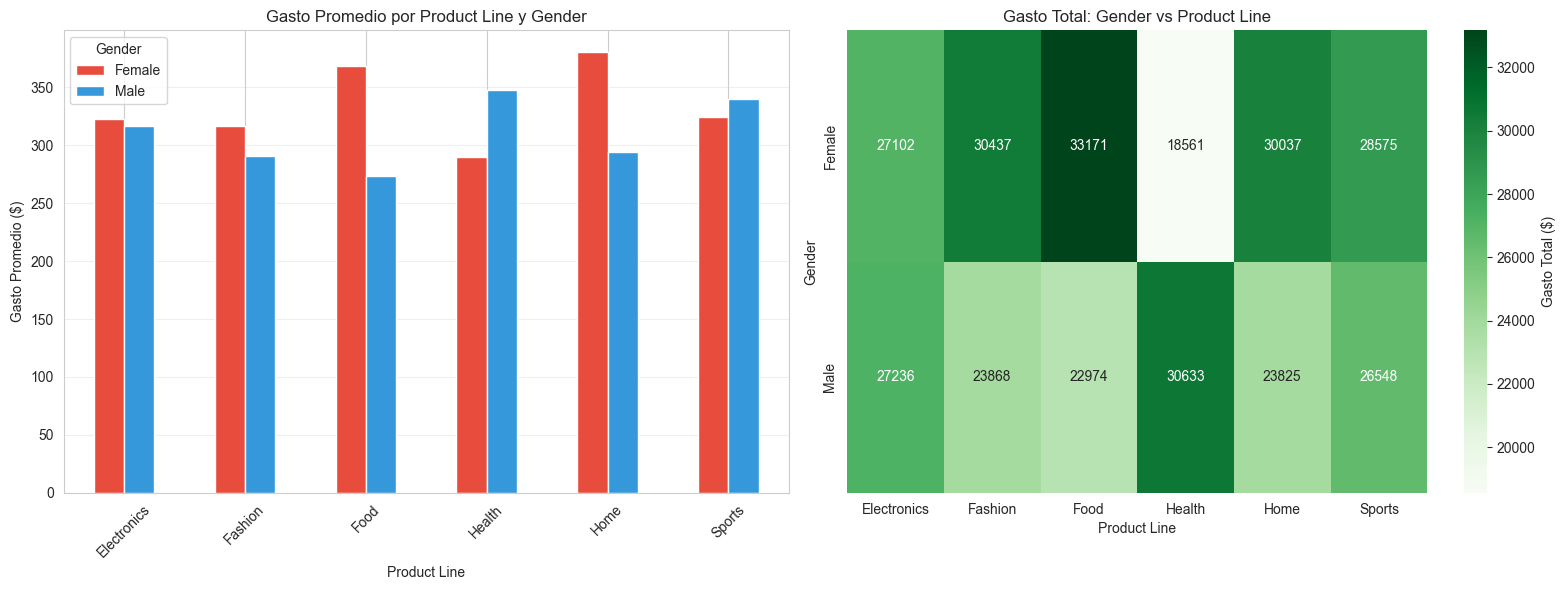


--- 6. Análisis de Relación: Quantity vs Unit Price ---


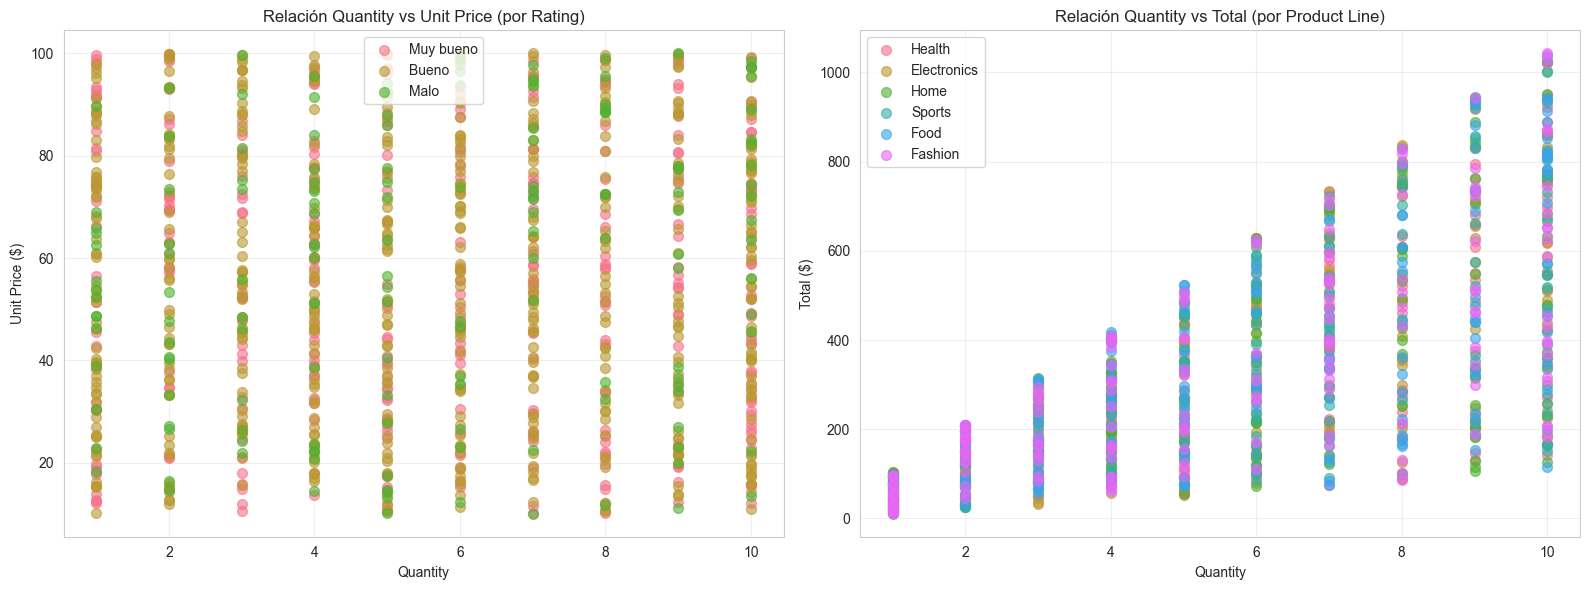


--- 7. Análisis de Rating_Category vs Customer Type ---

⭐ Distribución de Rating por Customer Type (%):
Customer type    Member  Normal
Rating_Category                
Bueno             49.50   54.11
Malo              16.97   13.63
Muy bueno         33.53   32.26


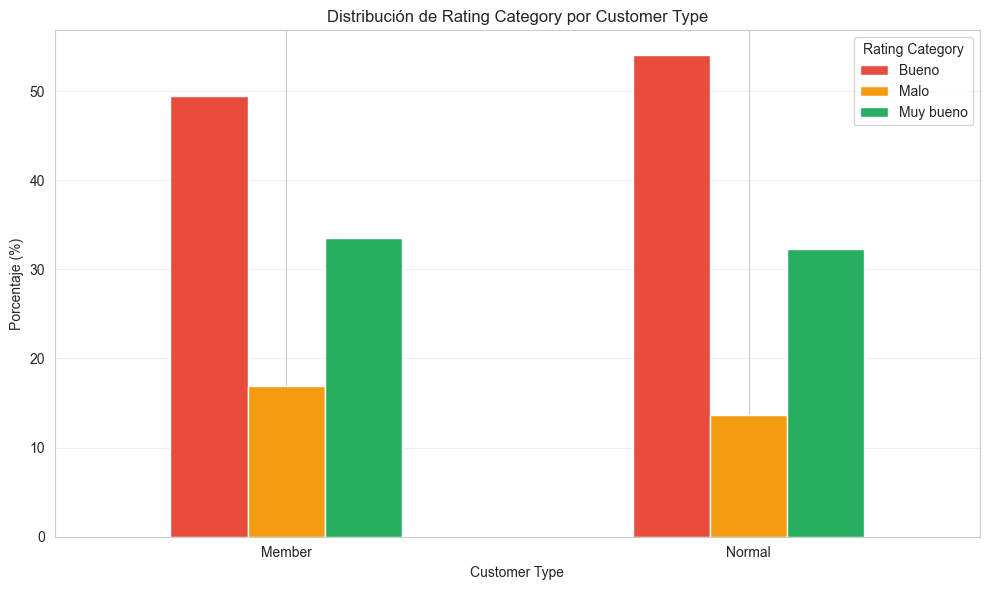


--- 8. Test de Chi-Cuadrado para Variables Categóricas ---

🔬 Análisis de Independencia (Chi-cuadrado):

Gender vs Product line:
  Chi-cuadrado: 5.7445
  P-valor: 0.3319
  Grados de libertad: 5
  ❌ No hay relación significativa (p >= 0.05)

Customer type vs Payment:
  Chi-cuadrado: 5.2170
  P-valor: 0.0736
  Grados de libertad: 2
  ❌ No hay relación significativa (p >= 0.05)

Rating_Category vs Customer type:
  Chi-cuadrado: 2.9682
  P-valor: 0.2267
  Grados de libertad: 2
  ❌ No hay relación significativa (p >= 0.05)

Gender vs Rating_Category:
  Chi-cuadrado: 5.1160
  P-valor: 0.0775
  Grados de libertad: 2
  ❌ No hay relación significativa (p >= 0.05)

✅ ANÁLISIS BIVARIADO COMPLETADO


In [7]:
from scipy.stats import chi2_contingency

# --- ANÁLISIS BIVARIADO ---

print("=" * 80)
print("📊 ANÁLISIS BIVARIADO - RELACIONES ENTRE VARIABLES")
print("=" * 80)

# Configurar el estilo de visualización
sns.set_palette("husl")

# 1. ANÁLISIS: Variables Numéricas vs Rating_Category
print("\n--- 1. Análisis de Variables Numéricas por Rating_Category ---")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Análisis Bivariado: Variables Numéricas por Rating_Category', fontsize=16, fontweight='bold')

for idx, col in enumerate(numerical_cols):
    # Boxplot
    ax1 = axes[0, idx]
    sns.boxplot(data=df_eda, x='Rating_Category', y=col, ax=ax1, order=['Malo', 'Bueno', 'Muy bueno'])
    ax1.set_title(f'{col} por Rating_Category')
    ax1.set_xlabel('Rating Category')
    ax1.grid(True, alpha=0.3)
    
    # Violin plot para ver distribución
    ax2 = axes[1, idx]
    sns.violinplot(data=df_eda, x='Rating_Category', y=col, ax=ax2, order=['Malo', 'Bueno', 'Muy bueno'])
    ax2.set_title(f'Distribución de {col} por Rating')
    ax2.set_xlabel('Rating Category')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas por Rating_Category
print("\n📈 Estadísticas de Variables Numéricas por Rating_Category:")
for col in numerical_cols:
    print(f"\n--- {col} ---")
    stats = df_eda.groupby('Rating_Category')[col].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
    print(stats)

# 2. ANÁLISIS: Product line vs Variables Numéricas
print("\n--- 2. Análisis de Product Line vs Variables Numéricas ---")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Variables Numéricas por Product Line', fontsize=16, fontweight='bold')

for idx, col in enumerate(numerical_cols):
    sns.barplot(data=df_eda, x='Product line', y=col, ax=axes[idx], 
                estimator='mean', errorbar='sd', palette='viridis')
    axes[idx].set_title(f'Promedio de {col} por Product Line')
    axes[idx].set_xlabel('Product Line')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 3. ANÁLISIS: Gender vs Product line
print("\n--- 3. Análisis de Gender vs Product Line ---")

# Tabla de contingencia
gender_product_ct = pd.crosstab(df_eda['Gender'], df_eda['Product line'], normalize='index') * 100
print("\n📊 Distribución de Product Line por Gender (%):")
print(gender_product_ct.round(2))

# Visualización con heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap de frecuencias absolutas
sns.heatmap(pd.crosstab(df_eda['Gender'], df_eda['Product line']), 
            annot=True, fmt='d', cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Frecuencia'})
axes[0].set_title('Frecuencia: Gender vs Product Line')
axes[0].set_xlabel('Product Line')
axes[0].set_ylabel('Gender')

# Heatmap de porcentajes
sns.heatmap(gender_product_ct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1], 
            cbar_kws={'label': 'Porcentaje (%)'})
axes[1].set_title('Porcentaje: Gender vs Product Line')
axes[1].set_xlabel('Product Line')
axes[1].set_ylabel('Gender')

plt.tight_layout()
plt.show()

# 4. ANÁLISIS: Customer type vs Payment Method
print("\n--- 4. Análisis de Customer Type vs Payment Method ---")

# Tabla de contingencia
customer_payment_ct = pd.crosstab(df_eda['Customer type'], df_eda['Payment'], normalize='index') * 100
print("\n💳 Distribución de Payment por Customer Type (%):")
print(customer_payment_ct.round(2))

# Visualización con gráfico de barras apiladas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras agrupadas
pd.crosstab(df_eda['Customer type'], df_eda['Payment']).plot(
    kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4', '#95E1D3'])
axes[0].set_title('Frecuencia de Payment Method por Customer Type')
axes[0].set_xlabel('Customer Type')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(title='Payment Method')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

# Barras apiladas (100%)
customer_payment_ct.plot(kind='bar', stacked=True, ax=axes[1], 
                        color=['#FF6B6B', '#4ECDC4', '#95E1D3'])
axes[1].set_title('Distribución % de Payment Method por Customer Type')
axes[1].set_xlabel('Customer Type')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(title='Payment Method')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 5. ANÁLISIS: Total Gastado por Gender y Product Line
print("\n--- 5. Análisis de Gasto Total por Gender y Product Line ---")

gender_product_total = df_eda.groupby(['Gender', 'Product line'])['Total'].agg(['sum', 'mean', 'count']).round(2)
print("\n💰 Análisis de Gasto por Gender y Product Line:")
print(gender_product_total)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras agrupadas
gender_product_mean = df_eda.groupby(['Product line', 'Gender'])['Total'].mean().unstack()
gender_product_mean.plot(kind='bar', ax=axes[0], color=['#E74C3C', '#3498DB'])
axes[0].set_title('Gasto Promedio por Product Line y Gender')
axes[0].set_xlabel('Product Line')
axes[0].set_ylabel('Gasto Promedio ($)')
axes[0].legend(title='Gender')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Heatmap de gasto total
gender_product_sum = df_eda.pivot_table(values='Total', index='Gender', 
                                        columns='Product line', aggfunc='sum')
sns.heatmap(gender_product_sum, annot=True, fmt='.0f', cmap='Greens', ax=axes[1],
            cbar_kws={'label': 'Gasto Total ($)'})
axes[1].set_title('Gasto Total: Gender vs Product Line')
axes[1].set_xlabel('Product Line')
axes[1].set_ylabel('Gender')

plt.tight_layout()
plt.show()

# 6. ANÁLISIS: Quantity vs Unit Price (Scatter plot)
print("\n--- 6. Análisis de Relación: Quantity vs Unit Price ---")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot con colores por Rating_Category
for category in df_eda['Rating_Category'].unique():
    data = df_eda[df_eda['Rating_Category'] == category]
    axes[0].scatter(data['Quantity'], data['Unit price'], 
                   label=category, alpha=0.6, s=50)
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Unit Price ($)')
axes[0].set_title('Relación Quantity vs Unit Price (por Rating)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scatter plot con colores por Product line
for product in df_eda['Product line'].unique():
    data = df_eda[df_eda['Product line'] == product]
    axes[1].scatter(data['Quantity'], data['Total'], 
                   label=product, alpha=0.6, s=50)
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Total ($)')
axes[1].set_title('Relación Quantity vs Total (por Product Line)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7. ANÁLISIS: Rating_Category vs Customer Type
print("\n--- 7. Análisis de Rating_Category vs Customer Type ---")

rating_customer_ct = pd.crosstab(df_eda['Rating_Category'], df_eda['Customer type'], 
                                normalize='columns') * 100
print("\n⭐ Distribución de Rating por Customer Type (%):")
print(rating_customer_ct.round(2))

fig, ax = plt.subplots(figsize=(10, 6))
rating_customer_ct.T.plot(kind='bar', ax=ax, color=['#E74C3C', '#F39C12', '#27AE60'])
ax.set_title('Distribución de Rating Category por Customer Type')
ax.set_xlabel('Customer Type')
ax.set_ylabel('Porcentaje (%)')
ax.legend(title='Rating Category')
ax.tick_params(axis='x', rotation=0)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 8. RESUMEN: Correlación entre variables categóricas (Chi-cuadrado)
print("\n--- 8. Test de Chi-Cuadrado para Variables Categóricas ---")


categorical_pairs = [
    ('Gender', 'Product line'),
    ('Customer type', 'Payment'),
    ('Rating_Category', 'Customer type'),
    ('Gender', 'Rating_Category')
]

print("\n🔬 Análisis de Independencia (Chi-cuadrado):")
for var1, var2 in categorical_pairs:
    contingency_table = pd.crosstab(df_eda[var1], df_eda[var2])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    print(f"\n{var1} vs {var2}:")
    print(f"  Chi-cuadrado: {chi2:.4f}")
    print(f"  P-valor: {p_value:.4f}")
    print(f"  Grados de libertad: {dof}")
    
    if p_value < 0.05:
        print(f"  ✅ Hay relación significativa (p < 0.05)")
    else:
        print(f"  ❌ No hay relación significativa (p >= 0.05)")

print("\n" + "=" * 80)
print("✅ ANÁLISIS BIVARIADO COMPLETADO")
print("=" * 80)

In [8]:
# Convertir columna Date a tipo datetime
df_eda['Date'] = pd.to_datetime(df_eda['Date'])

# Crear embedding concatenando las columnas especificadas
df_eda['Customer_Profile'] = (df_eda['Customer type'] + '_' + 
                             df_eda['Gender'] + '_' + 
                             df_eda['Payment'] + '_' + 
                             df_eda['Rating_Category'])

print("--- Embedding Customer Profile creado ---")
print(f"Valores únicos del embedding: {df_eda['Customer_Profile'].nunique()}")
print("\nPrimeros 10 perfiles únicos:")
print(df_eda['Customer_Profile'].value_counts().head(10))

# Análisis RFM por Product line
print("\n--- Análisis RFM por Product Line ---")

# Calcular fecha máxima para Recency
max_date = df_eda['Date'].max()

# Crear análisis RFM agrupado por Product line
rfm_by_product = df_eda.groupby('Product line').agg({
    'Date': [lambda x: (max_date - x.max()).days, 'count'],  # Recency y Frequency
    'Total': 'sum'    # Monetary: suma total gastada
}).round(2)

# Aplanar los nombres de columnas multi-nivel
rfm_by_product.columns = ['Recency_days', 'Frequency', 'Monetary']

# Agregar estadísticas adicionales
additional_stats = df_eda.groupby('Product line').agg({
    'Total': ['mean', 'std'],
    'Quantity': 'sum',
    'Customer_Profile': 'nunique'
}).round(2)

# Aplanar nombres de columnas
additional_stats.columns = ['Avg_Transaction', 'Std_Transaction', 'Total_Items', 'Unique_Profiles']

# Combinar ambos análisis
rfm_analysis = pd.concat([rfm_by_product, additional_stats], axis=1)

print(rfm_analysis)

# Crear ranking por cada métrica
rfm_analysis['Recency_Rank'] = rfm_analysis['Recency_days'].rank(ascending=True)  # Menor recency = mejor
rfm_analysis['Frequency_Rank'] = rfm_analysis['Frequency'].rank(ascending=False)  # Mayor frequency = mejor  
rfm_analysis['Monetary_Rank'] = rfm_analysis['Monetary'].rank(ascending=False)    # Mayor monetary = mejor

print(f"\n--- Ranking RFM por Product Line ---")
print(rfm_analysis[['Recency_Rank', 'Frequency_Rank', 'Monetary_Rank']].sort_values('Monetary_Rank'))

--- Embedding Customer Profile creado ---
Valores únicos del embedding: 36

Primeros 10 perfiles únicos:
Customer_Profile
Normal_Male_Ewallet_Bueno          59
Normal_Male_Cash_Bueno             58
Member_Male_Cash_Bueno             46
Normal_Female_Ewallet_Bueno        45
Member_Female_Cash_Bueno           44
Member_Female_Credit card_Bueno    41
Normal_Female_Cash_Bueno           41
Member_Male_Ewallet_Bueno          40
Member_Male_Credit card_Bueno      39
Member_Female_Ewallet_Bueno        38
Name: count, dtype: int64

--- Análisis RFM por Product Line ---
              Recency_days  Frequency  Monetary  Avg_Transaction  \
Product line                                                       
Electronics              0        170  54337.53           319.63   
Fashion                  0        178  54305.90           305.09   
Food                     0        174  56144.84           322.67   
Health                   0        152  49193.74           323.64   
Home                     

--- Datos RFM Normalizados ---
              Recency_scaled  Frequency_scaled  Monetary_scaled
Product line                                                   
Electronics              0.0          0.383482         0.231820
Fashion                  0.0          1.303840         0.217435
Food                     0.0          0.843661         1.053751
Health                   0.0         -1.687323        -2.107481
Home                     0.0         -0.766965         0.015516
Sports                   0.0         -0.076696         0.588960

--- PERFILES DE CLUSTERS RFM ---
        Recency_days      Frequency        Monetary          Avg_Transaction  \
                mean  std      mean   std      mean      std            mean   
Cluster                                                                        
0                0.0  0.0     174.0  4.00  54929.42  1052.70          315.80   
1                0.0  NaN     152.0   NaN  49193.74      NaN          323.64   
2                0.0  0

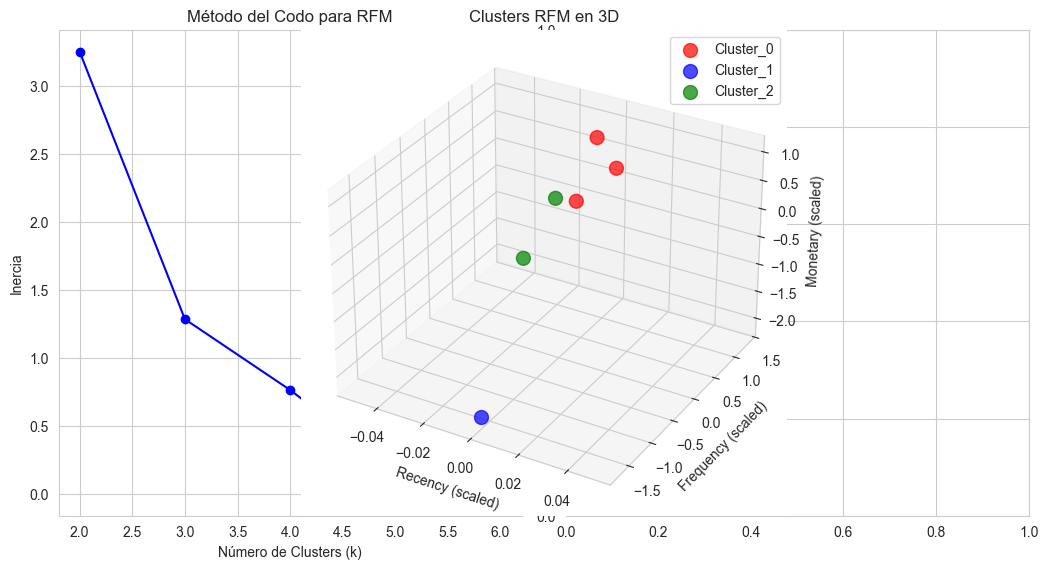


--- RESULTADO FINAL: RFM CON CLUSTERS ---
              Frequency  Monetary  Avg_Transaction  Cluster
Product line                                               
Electronics         170  54337.53           319.63        0
Fashion             178  54305.90           305.09        0
Food                174  56144.84           322.67        0
Health              152  49193.74           323.64        1
Home                160  53861.91           336.64        2
Sports              166  55122.83           332.07        2


In [9]:
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

# --- CLUSTERING BASADO EN ANÁLISIS RFM ---

# Preparar datos para clustering RFM
rfm_features = rfm_analysis[['Recency_days', 'Frequency', 'Monetary']].copy()

# Normalizar las características para clustering
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)
rfm_scaled_df = pd.DataFrame(rfm_scaled, 
                            columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'],
                            index=rfm_features.index)

print("--- Datos RFM Normalizados ---")
print(rfm_scaled_df)

# Aplicar K-Means clustering

# Determinar número óptimo de clusters usando método del codo
inertias = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

# Crear visualización del método del codo
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para RFM')
plt.grid(True)

# Aplicar clustering con k=3 (número óptimo estimado)
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm_analysis['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

# Crear perfiles de clusters
print("\n--- PERFILES DE CLUSTERS RFM ---")
cluster_profiles = rfm_analysis.groupby('Cluster').agg({
    'Recency_days': ['mean', 'std'],
    'Frequency': ['mean', 'std'],
    'Monetary': ['mean', 'std'],
    'Avg_Transaction': 'mean',
    'Unique_Profiles': 'mean'
}).round(2)

print(cluster_profiles)

# Asignar nombres descriptivos a los clusters
cluster_names = {
    0: 'Cluster_0',
    1: 'Cluster_1', 
    2: 'Cluster_2'
}

# Analizar características de cada cluster
print(f"\n--- ANÁLISIS POR CLUSTER ---")
for cluster_id in sorted(rfm_analysis['Cluster'].unique()):
    cluster_data = rfm_analysis[rfm_analysis['Cluster'] == cluster_id]
    print(f"\n{cluster_names[cluster_id]}:")
    print(f"Product Lines: {list(cluster_data.index)}")
    print(f"Promedio Monetary: ${cluster_data['Monetary'].mean():.2f}")
    print(f"Promedio Frequency: {cluster_data['Frequency'].mean():.1f}")
    print(f"Promedio Transaction: ${cluster_data['Avg_Transaction'].mean():.2f}")

# Visualizar clusters en 3D

plt.subplot(1, 2, 2)
ax = plt.axes(projection='3d')

colors = ['red', 'blue', 'green']
for i, cluster_id in enumerate(sorted(rfm_analysis['Cluster'].unique())):
    cluster_data = rfm_scaled_df[rfm_analysis['Cluster'] == cluster_id]
    ax.scatter(cluster_data['Recency_scaled'], 
              cluster_data['Frequency_scaled'], 
              cluster_data['Monetary_scaled'],
              c=colors[i], 
              label=f'{cluster_names[cluster_id]}',
              s=100, alpha=0.7)

ax.set_xlabel('Recency (scaled)')
ax.set_ylabel('Frequency (scaled)')
ax.set_zlabel('Monetary (scaled)')
ax.set_title('Clusters RFM en 3D')
ax.legend()

plt.tight_layout()
plt.show()

# Mostrar resultado final con clusters
print(f"\n--- RESULTADO FINAL: RFM CON CLUSTERS ---")
print(rfm_analysis[['Frequency', 'Monetary', 'Avg_Transaction', 'Cluster']].sort_values('Cluster'))

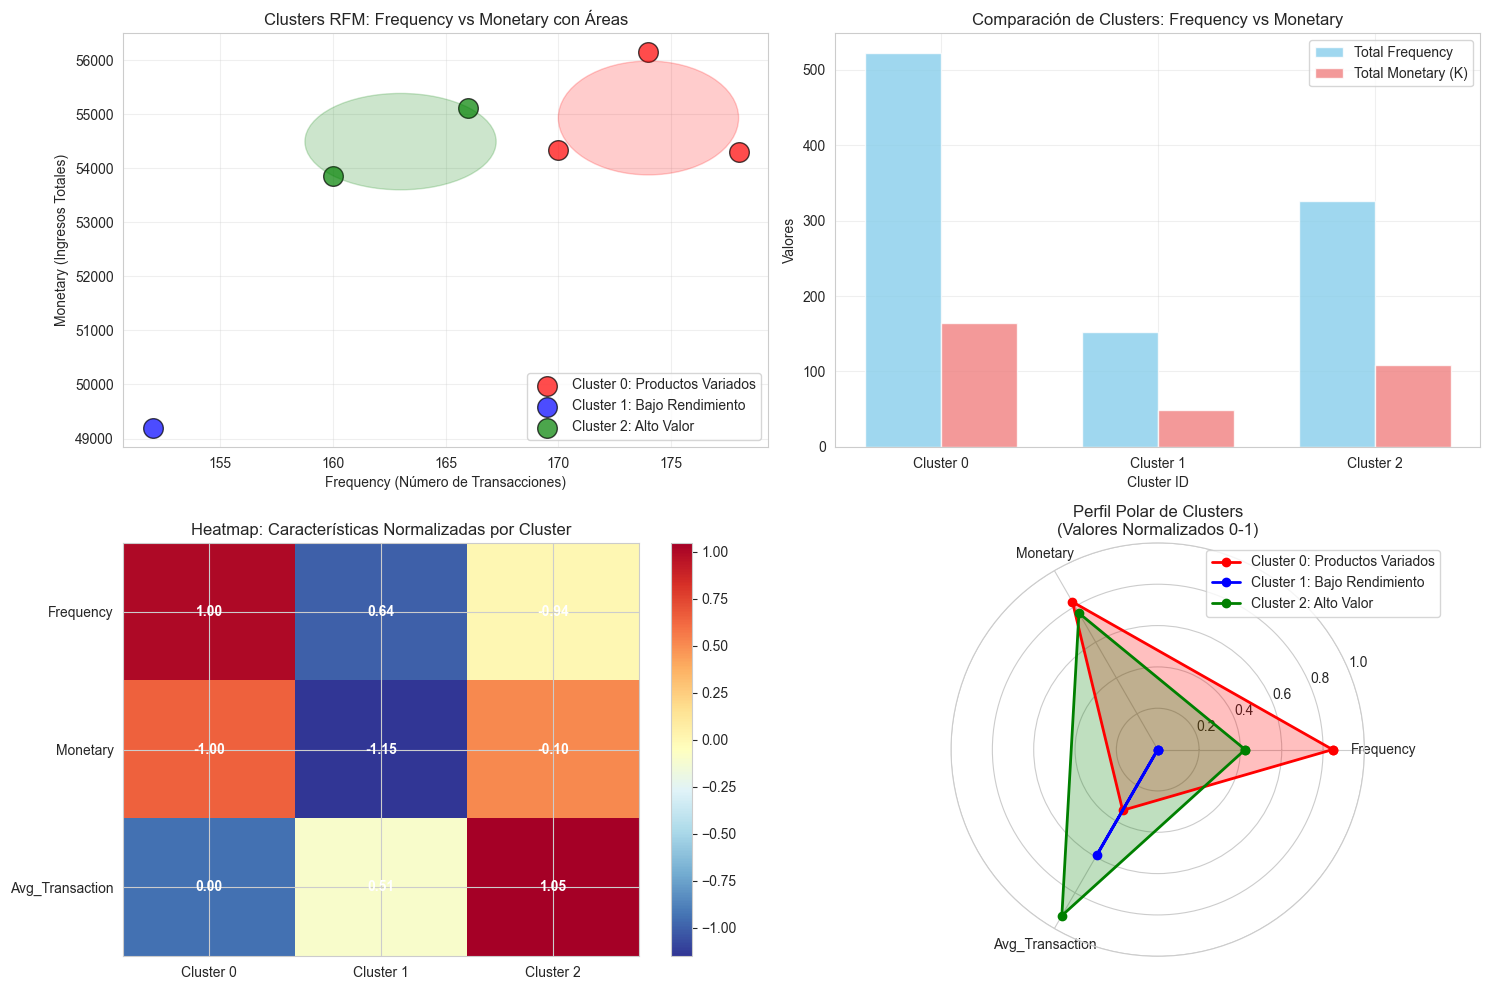

--- ESTADÍSTICAS DETALLADAS DE CLUSTERS ---

Cluster 0: Productos Variados:
  • Product Lines: Electronics, Fashion, Food
  • Frequency Total: 522 transacciones
  • Monetary Total: $164,788.27
  • Avg Transaction: $315.80
  • Total Items: 2,825

Cluster 1: Bajo Rendimiento:
  • Product Lines: Health
  • Frequency Total: 152 transacciones
  • Monetary Total: $49,193.74
  • Avg Transaction: $323.64
  • Total Items: 854

Cluster 2: Alto Valor:
  • Product Lines: Home, Sports
  • Frequency Total: 326 transacciones
  • Monetary Total: $108,984.74
  • Avg Transaction: $334.36
  • Total Items: 1,831


In [10]:
from matplotlib.patches import Ellipse

# Crear visualizaciones de los clusters con áreas

# Configurar el tamaño de la figura
plt.figure(figsize=(15, 10))

# 1. Gráfico de dispersión 2D con áreas (Frequency vs Monetary)
plt.subplot(2, 2, 1)
colors = ['red', 'blue', 'green']
cluster_labels = ['Cluster 0: Productos Variados', 'Cluster 1: Bajo Rendimiento', 'Cluster 2: Alto Valor']

for i, cluster_id in enumerate(sorted(rfm_analysis['Cluster'].unique())):
    cluster_data = rfm_analysis[rfm_analysis['Cluster'] == cluster_id]
    
    # Scatter plot
    plt.scatter(cluster_data['Frequency'], cluster_data['Monetary'], 
               c=colors[i], s=200, alpha=0.7, label=cluster_labels[i], edgecolors='black')
    
    # Añadir elipses para mostrar el área de cada cluster
    if len(cluster_data) > 1:
        # Calcular centro y dispersión
        center_x = cluster_data['Frequency'].mean()
        center_y = cluster_data['Monetary'].mean()
        std_x = cluster_data['Frequency'].std() * 2
        std_y = cluster_data['Monetary'].std() * 2
        
        ellipse = Ellipse((center_x, center_y), std_x, std_y, 
                         alpha=0.2, color=colors[i])
        plt.gca().add_patch(ellipse)

plt.xlabel('Frequency (Número de Transacciones)')
plt.ylabel('Monetary (Ingresos Totales)')
plt.title('Clusters RFM: Frequency vs Monetary con Áreas')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Gráfico de barras apiladas por cluster
plt.subplot(2, 2, 2)
cluster_summary = rfm_analysis.groupby('Cluster').agg({
    'Frequency': 'sum',
    'Monetary': 'sum'
}).reset_index()

x_pos = range(len(cluster_summary))
width = 0.35

plt.bar([i - width/2 for i in x_pos], cluster_summary['Frequency'], 
        width, label='Total Frequency', color='skyblue', alpha=0.8)
plt.bar([i + width/2 for i in x_pos], cluster_summary['Monetary']/1000, 
        width, label='Total Monetary (K)', color='lightcoral', alpha=0.8)

plt.xlabel('Cluster ID')
plt.ylabel('Valores')
plt.title('Comparación de Clusters: Frequency vs Monetary')
plt.xticks(x_pos, [f'Cluster {i}' for i in cluster_summary['Cluster']])
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Heatmap de características por cluster
plt.subplot(2, 2, 3)
heatmap_data = rfm_analysis.groupby('Cluster')[['Frequency', 'Monetary', 'Avg_Transaction']].mean()
heatmap_data_normalized = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()

im = plt.imshow(heatmap_data_normalized.T, cmap='RdYlBu_r', aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(heatmap_data.index)), [f'Cluster {i}' for i in heatmap_data.index])
plt.yticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.title('Heatmap: Características Normalizadas por Cluster')

# Añadir valores en el heatmap
for i in range(len(heatmap_data.columns)):
    for j in range(len(heatmap_data.index)):
        plt.text(j, i, f'{heatmap_data_normalized.iloc[i, j]:.2f}', 
                ha='center', va='center', color='white', fontweight='bold')

# 4. Gráfico de área polar para mostrar perfiles de cluster
plt.subplot(2, 2, 4, projection='polar')

# Normalizar datos para el gráfico polar (0-1)
metrics = ['Frequency', 'Monetary', 'Avg_Transaction']
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # Cerrar el polígono

for i, cluster_id in enumerate(sorted(rfm_analysis['Cluster'].unique())):
    cluster_data = rfm_analysis[rfm_analysis['Cluster'] == cluster_id]
    values = []
    
    for metric in metrics:
        # Normalizar cada métrica entre 0 y 1
        norm_value = (cluster_data[metric].mean() - rfm_analysis[metric].min()) / \
                    (rfm_analysis[metric].max() - rfm_analysis[metric].min())
        values.append(norm_value)
    
    values += values[:1]  # Cerrar el polígono
    
    plt.plot(angles, values, 'o-', linewidth=2, label=cluster_labels[i], color=colors[i])
    plt.fill(angles, values, alpha=0.25, color=colors[i])

plt.xticks(angles[:-1], metrics)
plt.ylim(0, 1)
plt.title('Perfil Polar de Clusters\n(Valores Normalizados 0-1)')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))

plt.tight_layout()
plt.show()

# Mostrar estadísticas detalladas de cada cluster
print("--- ESTADÍSTICAS DETALLADAS DE CLUSTERS ---")
for cluster_id in sorted(rfm_analysis['Cluster'].unique()):
    cluster_data = rfm_analysis[rfm_analysis['Cluster'] == cluster_id]
    print(f"\n{cluster_labels[cluster_id]}:")
    print(f"  • Product Lines: {', '.join(cluster_data.index.tolist())}")
    print(f"  • Frequency Total: {cluster_data['Frequency'].sum():,} transacciones")
    print(f"  • Monetary Total: ${cluster_data['Monetary'].sum():,.2f}")
    print(f"  • Avg Transaction: ${cluster_data['Avg_Transaction'].mean():.2f}")
    print(f"  • Total Items: {cluster_data['Total_Items'].sum():,}")

In [11]:
import random

# --- CREACIÓN DE BUYER PERSONAS BASADO EN LOS CLUSTERS ---

# Definir características detalladas para cada cluster
cluster_personas = {
    0: {  # Cluster 0: Productos Variados
        'cluster_name': 'Compradores Diversificados',
        'characteristics': {
            'frequency': 'Alta (174 transacciones promedio)',
            'monetary': 'Medio-Alto ($54,929)',
            'avg_transaction': 'Moderado ($315.80)',
            'behavior': 'Compran variedad de productos con frecuencia media-alta'
        },
        'personas': [
            {
                'name': 'María González',
                'age': 35,
                'occupation': 'Gerente de Marketing',
                'income': '$45,000 - $60,000',
                'lifestyle': 'Profesional activa, madre de familia',
                'shopping_behavior': 'Compra regularmente productos de diferentes categorías, busca calidad-precio',
                'preferred_products': ['Electronics', 'Fashion', 'Food'],
                'pain_points': ['Falta de tiempo', 'Necesita productos confiables'],
                'motivations': ['Eficiencia', 'Calidad', 'Conveniencia'],
                'preferred_channels': ['Online shopping', 'Apps móviles', 'Email marketing']
            },
            {
                'name': 'Carlos Rodríguez',
                'age': 42,
                'occupation': 'Ingeniero de Software',
                'income': '$50,000 - $70,000',
                'lifestyle': 'Tech-savvy, valora la innovación',
                'shopping_behavior': 'Investiga antes de comprar, compara precios, busca ofertas',
                'preferred_products': ['Electronics', 'Fashion', 'Food'],
                'pain_points': ['Productos de baja calidad', 'Falta de información técnica'],
                'motivations': ['Innovación', 'Tecnología', 'Valor por dinero'],
                'preferred_channels': ['Reviews online', 'Comparadores de precios', 'Redes sociales']
            }
        ]
    },
    1: {  # Cluster 1: Bajo Rendimiento
        'cluster_name': 'Compradores Ocasionales',
        'characteristics': {
            'frequency': 'Baja (152 transacciones)',
            'monetary': 'Bajo ($49,194)',
            'avg_transaction': 'Alto ($323.64)',
            'behavior': 'Compras menos frecuentes pero de mayor valor unitario'
        },
        'personas': [
            {
                'name': 'Ana Martínez',
                'age': 28,
                'occupation': 'Estudiante de Posgrado',
                'income': '$20,000 - $35,000',
                'lifestyle': 'Estudiante, presupuesto limitado',
                'shopping_behavior': 'Compras planificadas, busca descuentos y promociones',
                'preferred_products': ['Health'],
                'pain_points': ['Presupuesto limitado', 'Necesita productos duraderos'],
                'motivations': ['Precio', 'Necesidad', 'Salud y bienestar'],
                'preferred_channels': ['Cupones de descuento', 'Ofertas estudiantiles', 'Social media']
            }
        ]
    },
    2: {  # Cluster 2: Alto Valor
        'cluster_name': 'Compradores Premium',
        'characteristics': {
            'frequency': 'Media (163 transacciones)',
            'monetary': 'Alto ($54,492)',
            'avg_transaction': 'Muy Alto ($334.36)',
            'behavior': 'Gastan más por transacción, prefieren calidad premium'
        },
        'personas': [
            {
                'name': 'Roberto Silva',
                'age': 45,
                'occupation': 'Director Ejecutivo',
                'income': '$80,000+',
                'lifestyle': 'Alto poder adquisitivo, valora el lujo',
                'shopping_behavior': 'Compra productos premium, valora la calidad sobre el precio',
                'preferred_products': ['Home', 'Sports'],
                'pain_points': ['Falta de tiempo', 'Productos que no cumplan expectativas'],
                'motivations': ['Status', 'Calidad superior', 'Exclusividad'],
                'preferred_channels': ['Tiendas premium', 'Asesores personales', 'Eventos exclusivos']
            },
            {
                'name': 'Patricia López',
                'age': 38,
                'occupation': 'Arquitecta',
                'income': '$60,000 - $80,000',
                'lifestyle': 'Profesional creativa, valora el diseño',
                'shopping_behavior': 'Busca productos únicos y de alta calidad, influenciada por tendencias',
                'preferred_products': ['Home', 'Sports'],
                'pain_points': ['Productos genéricos', 'Falta de personalización'],
                'motivations': ['Diseño', 'Originalidad', 'Calidad'],
                'preferred_channels': ['Instagram', 'Influencers', 'Showrooms']
            }
        ]
    }
}

# --- MOSTRAR BUYER PERSONAS ---
print("=" * 80)
print("🎯 BUYER PERSONAS BASADOS EN ANÁLISIS RFM")
print("=" * 80)

for cluster_id, data in cluster_personas.items():
    print(f"\n{'🔸' * 3} CLUSTER {cluster_id}: {data['cluster_name']} {'🔸' * 3}")
    
    # Mostrar características del cluster
    print(f"\n📊 Características del Cluster:")
    for key, value in data['characteristics'].items():
        print(f"   • {key.replace('_', ' ').title()}: {value}")
    
    # Mostrar personas
    print(f"\n👥 Buyer Personas ({len(data['personas'])} personas):")
    
    for i, persona in enumerate(data['personas'], 1):
        print(f"\n   🧑‍💼 PERSONA {i}: {persona['name']}")
        print(f"      • Edad: {persona['age']} años")
        print(f"      • Ocupación: {persona['occupation']}")
        print(f"      • Ingresos: {persona['income']}")
        print(f"      • Estilo de vida: {persona['lifestyle']}")
        print(f"      • Comportamiento de compra: {persona['shopping_behavior']}")
        print(f"      • Productos preferidos: {', '.join(persona['preferred_products'])}")
        print(f"      • Puntos de dolor: {', '.join(persona['pain_points'])}")
        print(f"      • Motivaciones: {', '.join(persona['motivations'])}")
        print(f"      • Canales preferidos: {', '.join(persona['preferred_channels'])}")

# --- ESTRATEGIAS DE MARKETING POR CLUSTER ---
print("\n" + "=" * 80)
print("📈 ESTRATEGIAS DE MARKETING PERSONALIZADAS")
print("=" * 80)

marketing_strategies = {
    0: {
        'strategy_name': 'Diversidad y Frecuencia',
        'primary_goal': 'Mantener alta frecuencia de compra y aumentar valor por transacción',
        'tactics': [
            '🛍️ Programa de fidelización con puntos por variedad de productos',
            '📧 Email marketing segmentado por categoría de producto',
            '🎁 Cross-selling: "Productos que también te pueden interesar"',
            '⏰ Recordatorios automáticos de recompra',
            '📱 App móvil con recomendaciones personalizadas',
            '🏷️ Descuentos por volumen en compras múltiples'
        ],
        'budget_allocation': 'Medio (35% del presupuesto)',
        'kpis': ['Frecuencia de compra', 'Cross-selling rate', 'Customer lifetime value']
    },
    1: {
        'strategy_name': 'Activación y Retención',
        'primary_goal': 'Aumentar frecuencia de compra y retener clientes de alto valor unitario',
        'tactics': [
            '🎯 Campañas de reactivación con ofertas especiales',
            '💊 Content marketing sobre salud y bienestar',
            '🏫 Programa de descuentos estudiantiles',
            '📧 Newsletter mensual con tips de salud',
            '🤝 Partnerships con universidades y centros de salud',
            '💰 Programa de referidos con incentivos'
        ],
        'budget_allocation': 'Alto (40% del presupuesto)',
        'kpis': ['Frecuencia de compra', 'Tasa de reactivación', 'Retención de clientes']
    },
    2: {
        'strategy_name': 'Premium y Exclusividad',
        'primary_goal': 'Mantener clientes premium y aumentar su valor de por vida',
        'tactics': [
            '👑 Programa VIP con servicios exclusivos',
            '🎨 Marketing experiencial y eventos premium',
            '📸 Colaboraciones con influencers de lifestyle',
            '🏡 Catálogos especializados en home & sports premium',
            '👔 Atención personalizada y asesorías one-on-one',
            '🚚 Servicio de entrega premium y personalización'
        ],
        'budget_allocation': 'Medio-Alto (25% del presupuesto)',
        'kpis': ['Average order value', 'Customer satisfaction', 'Net promoter score']
    }
}

for cluster_id, strategy in marketing_strategies.items():
    cluster_name = cluster_personas[cluster_id]['cluster_name']
    print(f"\n🎯 ESTRATEGIA PARA CLUSTER {cluster_id}: {cluster_name}")
    print(f"📋 Estrategia: {strategy['strategy_name']}")
    print(f"🎯 Objetivo Principal: {strategy['primary_goal']}")
    print(f"💰 Asignación de Presupuesto: {strategy['budget_allocation']}")
    
    print(f"\n📌 Tácticas Recomendadas:")
    for tactic in strategy['tactics']:
        print(f"   {tactic}")
    
    print(f"\n📊 KPIs a Medir:")
    for kpi in strategy['kpis']:
        print(f"   • {kpi}")

# --- CALENDARIO DE CAMPAÑAS ---
print("\n" + "=" * 80)
print("📅 CALENDARIO DE CAMPAÑAS SUGERIDO")
print("=" * 80)

campaign_calendar = {
    'Q1': {
        'Enero': [
            '🎯 Lanzar programa de fidelización (Cluster 0)',
            '💊 Campaña "Año Nuevo, Vida Saludable" (Cluster 1)',
            '👑 Evento VIP de lanzamiento de productos premium (Cluster 2)'
        ],
        'Febrero': [
            '💕 San Valentín: Cross-selling fashion + electronics (Cluster 0)',
            '🏫 Partnership con universidades - descuentos estudiantiles (Cluster 1)',
            '🏡 Catálogo especial "Home Premium" (Cluster 2)'
        ],
        'Marzo': [
            '📱 Lanzamiento de app móvil con recomendaciones (Cluster 0)',
            '📧 Newsletter mensual de salud (Cluster 1)',
            '📸 Colaboración con influencer de lifestyle (Cluster 2)'
        ]
    },
    'Q2': {
        'Abril-Junio': [
            '🌸 Campaña primaveral con productos variados (Cluster 0)',
            '🎓 Graduaciones: ofertas especiales en salud (Cluster 1)',
            '🏃‍♂️ Colección deportiva premium para verano (Cluster 2)'
        ]
    }
}

for quarter, months in campaign_calendar.items():
    print(f"\n📅 {quarter}:")
    for month, campaigns in months.items():
        print(f"   🗓️ {month}:")
        for campaign in campaigns:
            print(f"      {campaign}")

# --- MÉTRICAS DE ÉXITO ---
print("\n" + "=" * 80)
print("📊 MÉTRICAS DE ÉXITO ESPERADAS")
print("=" * 80)

success_metrics = {
    'Cluster 0 - Compradores Diversificados': {
        'current_metrics': {'frequency': 174, 'monetary': 54929, 'avg_transaction': 315.80},
        'target_metrics': {'frequency': 190, 'monetary': 60000, 'avg_transaction': 335},
        'improvement': {'frequency': '+9%', 'monetary': '+9%', 'avg_transaction': '+6%'}
    },
    'Cluster 1 - Compradores Ocasionales': {
        'current_metrics': {'frequency': 152, 'monetary': 49194, 'avg_transaction': 323.64},
        'target_metrics': {'frequency': 180, 'monetary': 58000, 'avg_transaction': 325},
        'improvement': {'frequency': '+18%', 'monetary': '+18%', 'avg_transaction': '+0.4%'}
    },
    'Cluster 2 - Compradores Premium': {
        'current_metrics': {'frequency': 163, 'monetary': 54492, 'avg_transaction': 334.36},
        'target_metrics': {'frequency': 170, 'monetary': 60000, 'avg_transaction': 355},
        'improvement': {'frequency': '+4%', 'monetary': '+10%', 'avg_transaction': '+6%'}
    }
}

for cluster_name, metrics in success_metrics.items():
    print(f"\n🎯 {cluster_name}:")
    print(f"   📊 Métricas Actuales:")
    print(f"      • Frecuencia: {metrics['current_metrics']['frequency']}")
    print(f"      • Monetary: ${metrics['current_metrics']['monetary']:,.0f}")
    print(f"      • Avg Transaction: ${metrics['current_metrics']['avg_transaction']:.2f}")
    
    print(f"   🎯 Objetivos 6 meses:")
    print(f"      • Frecuencia: {metrics['target_metrics']['frequency']} ({metrics['improvement']['frequency']})")
    print(f"      • Monetary: ${metrics['target_metrics']['monetary']:,.0f} ({metrics['improvement']['monetary']})")
    print(f"      • Avg Transaction: ${metrics['target_metrics']['avg_transaction']:.0f} ({metrics['improvement']['avg_transaction']})")

print(f"\n{'='*80}")
print("✅ BUYER PERSONAS Y ESTRATEGIAS DE MARKETING COMPLETADAS")
print("💡 Recomendación: Implementar gradualmente las estrategias comenzando por el Cluster 1")
print("📈 ROI Esperado: 15-20% de incremento en ingresos totales en 6 meses")
print("="*80)

🎯 BUYER PERSONAS BASADOS EN ANÁLISIS RFM

🔸🔸🔸 CLUSTER 0: Compradores Diversificados 🔸🔸🔸

📊 Características del Cluster:
   • Frequency: Alta (174 transacciones promedio)
   • Monetary: Medio-Alto ($54,929)
   • Avg Transaction: Moderado ($315.80)
   • Behavior: Compran variedad de productos con frecuencia media-alta

👥 Buyer Personas (2 personas):

   🧑‍💼 PERSONA 1: María González
      • Edad: 35 años
      • Ocupación: Gerente de Marketing
      • Ingresos: $45,000 - $60,000
      • Estilo de vida: Profesional activa, madre de familia
      • Comportamiento de compra: Compra regularmente productos de diferentes categorías, busca calidad-precio
      • Productos preferidos: Electronics, Fashion, Food
      • Puntos de dolor: Falta de tiempo, Necesita productos confiables
      • Motivaciones: Eficiencia, Calidad, Conveniencia
      • Canales preferidos: Online shopping, Apps móviles, Email marketing

   🧑‍💼 PERSONA 2: Carlos Rodríguez
      • Edad: 42 años
      • Ocupación: Ingeniero